In [1]:
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import torch
import numpy as np
from PIL import Image
import requests
import cv2

/Users/S100AHBD/Desktop/CityVision/cityvision/test_cityvision/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/Users/S100AHBD/Desktop/CityVision/cityvision/test_cityvision/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may s

In [2]:
fx = 480.35583204
fy = 437.11894211
cx = 354.90375117
cy = 249.48026187

dis_vec = np.array(
    [-4.09277234e-01, 1.89529196e-01, -2.03433425e-04, -2.01818939e-03, -5.22683299e-02]
)

camera_matrix = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]])

In [ ]:
# Load an image from file
image = Image.open("../assets/test4.jpg")

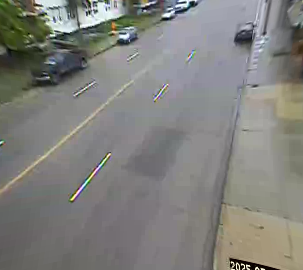

In [4]:
def undistort_image(image, camera_matrix, dis_vec):
	# Convert PIL image to numpy array for OpenCV
	img_array = np.array(image)
	
	h, w = img_array.shape[:2]
	
	# Get optimal new camera matrix
	newcameramtx, roi = cv2.getOptimalNewCameraMatrix(
		camera_matrix, dis_vec, (w, h), 1, (w, h)
	)
	
	# undistort
	undistorted_img = cv2.undistort(img_array, camera_matrix, dis_vec, None, newcameramtx)
	
	# crop the image
	x, y, w, h = roi
	undistorted_img = undistorted_img[y : y + h, x : x + w]
	
	# Convert back to PIL Image
	return Image.fromarray(undistorted_img)

# Apply the function to our image
undistorted_image = undistort_image(image, camera_matrix, dis_vec)

# Display the undistorted image
undistorted_image

In [39]:
def estimate_depth(image):
	"""
	Estimate depth from an image using a pre-trained depth estimation model.
	
	Args:
		image: PIL Image object
		
	Returns:
		prediction: depth map as numpy array
	"""
	CHECKPOINT = "depth-anything/Depth-Anything-V2-Metric-Outdoor-Large-hf"
	
	image_processor = AutoImageProcessor.from_pretrained(CHECKPOINT)
	model = AutoModelForDepthEstimation.from_pretrained(CHECKPOINT)
	
	inputs = image_processor(images=image, return_tensors="pt")
	
	with torch.no_grad():
		outputs = model(**inputs)
		predicted_depth = outputs.predicted_depth
	
	prediction = torch.nn.functional.interpolate(
		predicted_depth.unsqueeze(1),
		size=image.size[::-1],
		mode="bicubic",
		align_corners=False,
	)
	
	return prediction

# Apply the function to our image
prediction = estimate_depth(image)

In [12]:
# read all image in folder and add their depht map to matrix (w*h*n) n = number of images, w = width, h = height
def read_images_and_depths(folder_path):
	"""
	Read all images in a folder and estimate their depth maps.
	
	Args:
		folder_path: path to the folder containing images
	Returns:
		depth_maps: list of depth maps as numpy arrays
	"""
	import os
	# torch tensor with shape (h,w,n) where n = number of images
	depth_maps = []
	for filename in os.listdir(folder_path):
		if filename.endswith(".jpg") or filename.endswith(".png"):
			image_path = os.path.join(folder_path, filename)
			image = Image.open(image_path)
			# undistort the image
			undistorted_image = undistort_image(image, camera_matrix, dis_vec)
			# estimate depth
			depth_map = estimate_depth(undistorted_image).squeeze().cpu()
			# stack the depth map
			depth_maps.append(depth_map)

	torch_stack = torch.stack(depth_maps, dim=-1)

	# return numpy array with shape (h, w, n)
	torch_stack = torch_stack.numpy()
	return torch_stack

In [13]:
depth_maps = read_images_and_depths("../916_SCU1F4_2025-05-20_2345/")

In [14]:
depth_maps.shape  # Check the shape of the depth maps array to confirm dimensions

(270, 303, 25)

In [15]:
depth_maps[0][0]

array([14.522338 , 22.472044 , 25.330154 , 11.22368  , 19.962147 ,
       11.847605 , 21.093384 , 22.66133  , 13.0116415, 12.201912 ,
       20.61424  , 13.89218  , 22.032795 , 20.924156 , 21.404991 ,
       24.533642 , 24.31757  , 23.33607  , 20.087543 , 14.549574 ,
       20.524792 , 23.292128 , 12.135482 , 12.572164 , 30.789118 ],
      dtype=float32)

In [31]:
# take mean for all pixels and reduce to one depth map
mean_depth = np.mean(depth_maps, axis=2)

In [32]:
mean_depth[110][153] # Check the median of the first depth map

15.029239

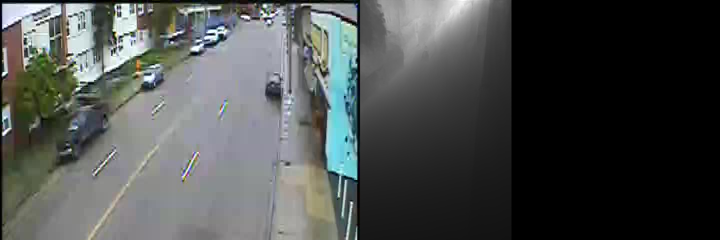

In [22]:
output = prediction.squeeze().cpu().numpy()
formatted = (mean_depth * 255 / np.max(mean_depth)).astype("uint8")
depth = Image.fromarray(formatted)

w, h = image.size
holder = Image.new("RGB", (w * 2, h // 2))
holder.paste(undistorted_image, (0, 0))

holder.paste(depth, (w, 0))
holder.paste(image, (0, 0))
holder.resize((w, h // 2))

In [ ]:
output

In [ ]:
prediction

In [ ]:
# squezee two first dimension the tensor
prediction = prediction.squeeze(0).squeeze(0)

In [23]:
prediction = prediction.cpu().numpy()
# Normalize the depth values
min_depth = np.min(mean_depth)
max_depth = np.max(mean_depth)
mean_depth_norm = (mean_depth - min_depth) / (max_depth - min_depth)

In [25]:
import numpy as np


import matplotlib.cm as cm


# Apply a colormap to the depth data
colormap = (
    cm.viridis
)  # You can choose other colormaps like 'plasma', 'inferno', 'magma', 'jet', etc.
depth_colored = colormap(mean_depth_norm)

# Convert the float values to uint8
depth_colored = (depth_colored[:, :, :3] * 255).astype("uint8")

# Create a new RGB image
depth = Image.fromarray(depth_colored)

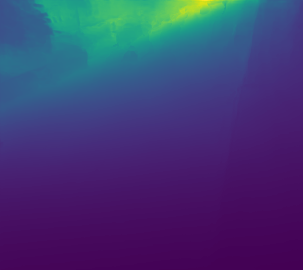

In [26]:
depth

In [33]:
# calculate distance between two points using depth map and camera matrix


def calculate_distance(depth_map, camera_matrix, x1, y1, x2, y2):
    # Get the depth values at the two points
    z1 = depth_map[y1, x1]
    z2 = depth_map[y2, x2]

    # Calculate the 3D coordinates of the two points
    p1 = np.array(
        [
            (x1 - camera_matrix[0, 2]) * z1 / camera_matrix[0, 0],
            (y1 - camera_matrix[1, 2]) * z1 / camera_matrix[1, 1],
            z1,
        ]
    )
    p2 = np.array(
        [
            (x2 - camera_matrix[0, 2]) * z2 / camera_matrix[0, 0],
            (y2 - camera_matrix[1, 2]) * z2 / camera_matrix[1, 1],
            z2,
        ]
    )

    # Calculate the distance between the two points
    distance = np.linalg.norm(p2 - p1)

    return distance

In [34]:
point_to_measure = [
    [[110, 153], [60, 201]],
    [[69, 98], [92, 81]]
]

In [35]:
for i, (point1, point2) in enumerate(point_to_measure):
    distance = calculate_distance(
        mean_depth, camera_matrix, point1[0], point1[1], point2[0], point2[1]
    )
    print(f"The distance between point {i+1} and point {i+2} is {distance:.2f} meters")

The distance between point 1 and point 2 is 3.74 meters
The distance between point 2 and point 3 is 4.58 meters


In [42]:
# find coordinates of the point with the maximum depth value
max_depth_index = np.unravel_index(np.argmax(mean_depth), mean_depth.shape)
max_depth_value = mean_depth[max_depth_index]
print(f"Maximum depth value: {max_depth_value} at coordinates {max_depth_index}")

# find coordinates of the point with the minimum depth value
min_depth_index = np.unravel_index(np.argmin(mean_depth), mean_depth.shape)
min_depth_value = mean_depth[min_depth_index]
print(f"Minimum depth value: {min_depth_value} at coordinates {min_depth_index}")

# draw lines between points on the depth map using cv2
import cv2
def draw_lines_on_depth_map(depth_map, points):
	depth_map_colored = cv2.applyColorMap(
		(depth_map * 255 / np.max(depth_map)).astype("uint8"), cv2.COLORMAP_JET
	)
	
	for point1, point2 in points:
		cv2.line(
			depth_map_colored,
			tuple(point1[::-1]),  # Reverse the order for (x, y)
			tuple(point2[::-1]),
			(0, 255, 0),  # Green color
			2,
		)
	
	return Image.fromarray(depth_map_colored)
depth_with_lines = draw_lines_on_depth_map(
	mean_depth, [(max_depth_index, min_depth_index)]
)
depth_with_lines.show()

Maximum depth value: 60.73259353637695 at coordinates (0, 203)
Minimum depth value: 4.211318016052246 at coordinates (268, 300)
